**14/08/2026** -- Supplementary figure S7: Trace plots of post-warmup MCMC chains for key parameters estimated in the Bayesian hierarchical model

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [2]:
library(dplyr)
library(brms)
library(rstan)
library(cmdstanr)
library(ggplot2)
library(bayesplot)
library(cowplot)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp

Loading 'brms' package (version 2.22.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:stats’:

    ar


Loading required package: StanHeaders


rstan version 2.32.6 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


This is cmdstanr v

In [3]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/model_setup.R"))

In [4]:
# Load config
cfg             <- yaml::read_yaml(file.path(root, "configs/bhm_fit_ppca_hu_15kiter_24threads_cfg.yaml"))
data_filepath   <- cfg$project$data_filepath
model_save_dir  <- cfg$project$model_save_dir

In [5]:
# Construct model file path
model_file <- build_modelfile(
    out_path    = model_save_dir,
    model_name  = cfg$model$name,
    outcome     = cfg$model$outcome,
    scale_y     = cfg$data$scale_y,
    pca_method  = cfg$pca$method,
    n_pcs       = cfg$pca$n_pcs,    
    mcmc_cfg    = cfg$mcmc,
    priors_cfg  = cfg$priors,
    max_year    = cfg$data$max_year
)

In [6]:
# Load model
model <- readRDS(model_file)

In [7]:
# Global (population-level) intercept and coefficients
params_global <- c(
    "b_Intercept",
    "b_PC1",                        # β₁: deprivation
    "b_urban_rural_caturban",       # β₂: urban
    "b_PC1:urban_rural_caturban",   # β₃: interaction
    "b_year"                        # γ: year trend
)

# Country-level SDs + residual sigma
params_sd <- c(
    "sd_country__Intercept",
    "sd_country__PC1",
    "sd_country__urban_rural_caturban",
    "sd_country__year",
    "sd_country__PC1:urban_rural_caturban",
    "sigma"
)

# Correlations
params_cor <- c(
    "cor_country__Intercept__PC1",
    "cor_country__Intercept__urban_rural_caturban",
    "cor_country__Intercept__PC1:urban_rural_caturban",
    "cor_country__Intercept__year",
    "cor_country__PC1__urban_rural_caturban",
    "cor_country__PC1__PC1:urban_rural_caturban",
    "cor_country__PC1__year",
    "cor_country__urban_rural_caturban__PC1:urban_rural_caturban",
    "cor_country__urban_rural_caturban__year",
    "cor_country__year__PC1:urban_rural_caturban"
)

In [8]:
nice_labels <- c(
    # Global coefficients
    "b_Intercept"                   = "alpha",
    "b_PC1"                         = "beta[1]",
    "b_urban_rural_caturban"        = "beta[2]",
    "b_PC1:urban_rural_caturban"    = "beta[3]",
    "b_year"                        = "gamma",

    # Country-level SDs
    "sd_country__Intercept"                 = "tau[alpha[c]]",
    "sd_country__PC1"                       = "tau[beta[1][c]]",
    "sd_country__urban_rural_caturban"      = "tau[beta[2][c]]",
    "sd_country__PC1:urban_rural_caturban"  = "tau[beta[3][c]]",
    "sd_country__year"                      = "tau[gamma[c]]",

    # Residual SD
    "sigma"                         = "sigma",

    # Correlations
    "cor_country__Intercept__PC1"   = "rho(alpha[c],beta[1][c])",
    "cor_country__Intercept__urban_rural_caturban"      = "rho(alpha[c],beta[2][c])",
    "cor_country__Intercept__PC1:urban_rural_caturban"  = "rho(alpha[c],beta[3][c])",
    "cor_country__Intercept__year"                      = "rho(alpha[c],gamma[c])",
    "cor_country__PC1__urban_rural_caturban"            = "rho(beta[1][c],beta[2][c])",
    "cor_country__PC1__PC1:urban_rural_caturban"        = "rho(beta[1][c],beta[3][c])",
    "cor_country__PC1__year"                            = "rho(beta[1][c],gamma[c])",
    "cor_country__urban_rural_caturban__PC1:urban_rural_caturban"   = "rho(beta[2][c],beta[3][c])",
    "cor_country__urban_rural_caturban__year"                       = "rho(beta[2][c],gamma[c])",
    "cor_country__year__PC1:urban_rural_caturban"                   = "rho(gamma[c],beta[3][c])"
)

In [9]:
make_trace_plot <- function(model, params, labels, title, base_size = 12) {
    draws <- as_draws_array(model)
    
    # Subset to selected params
    params <- intersect(params, dimnames(draws)[[3]])
    draws_sub <- draws[, , params]
    
    # Apply nice labels
    matched_labels <- labels[params]
    matched_labels[is.na(matched_labels)] <- params[is.na(matched_labels)]
    dimnames(draws_sub)[[3]] <- matched_labels
    
    # Shared theme
    shared_theme <- theme_minimal(base_size = base_size) +
        theme(
            strip.text      = element_text(size = base_size + 1),
            axis.text       = element_text(size = base_size - 1),
            axis.title      = element_blank(), #element_text(size = base_size),
            legend.text     = element_text(size = base_size),
            legend.title    = element_text(size = base_size + 1),
            plot.margin     = margin(5, 8, 5, 8),
            panel.grid      = element_blank(),
            axis.line       = element_line(colour = "black"),
            axis.ticks      =  element_line(colour = "black")#,
            # axis.text.x      = element_text(margin = margin(t = 3)),
            # axis.text.y      = element_text(margin = margin(r = 3))
        )
    
    # Histogram of param draws
    p_hist <- mcmc_hist(
        draws_sub,
        facet_args = list(
            ncol   = 1,
            scales = "free",
            strip.position = "top",
            labeller       = label_parsed
        )
    ) +
        shared_theme +
        labs(x = NULL, y = "Count") +
        scale_x_continuous(labels = scales::comma) +
        scale_y_continuous(labels = scales::comma,
                           expand = expansion(mult = c(0, 0.05))) +
        theme(legend.position = "none")
    
    # Trace plot
    p_trace <- mcmc_trace(
        draws_sub,
        facet_args = list(
            ncol   = 1,
            scales = "free",
            strip.position = "top",
            labeller       = label_parsed
        )
    ) +
        shared_theme +
        labs(x = "Iteration", y = NULL) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_continuous(labels = scales::comma) +
        theme(legend.position = "right")
    
    # Combine with patchwork
    combined <- (p_hist | p_trace) +
        plot_annotation(
            title = title,
            theme = theme(
                plot.title = element_text(
                    size   = base_size + 2,
                    face   = "bold",
                    hjust  = 0.5,
                    margin = margin(b = 10)
                )
            )
        )
    
    return(combined)
}

In [11]:
# Supplement trace plots 1: global coefficients
p1 <- make_trace_plot(
    model, params_global, nice_labels,
    title = "Global intercept and regression coefficients"
)

# Supplement trace plots 2: SDs and residual sigma
p2 <- make_trace_plot(
    model, params_sd, nice_labels,
    title = "SDs of country-level effects and residual SD"
)

# Supplement trace plots 3: correlations of random effects
p3 <- make_trace_plot(
    model, params_cor, nice_labels,
    title = "Correlations of country-level effects"
)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


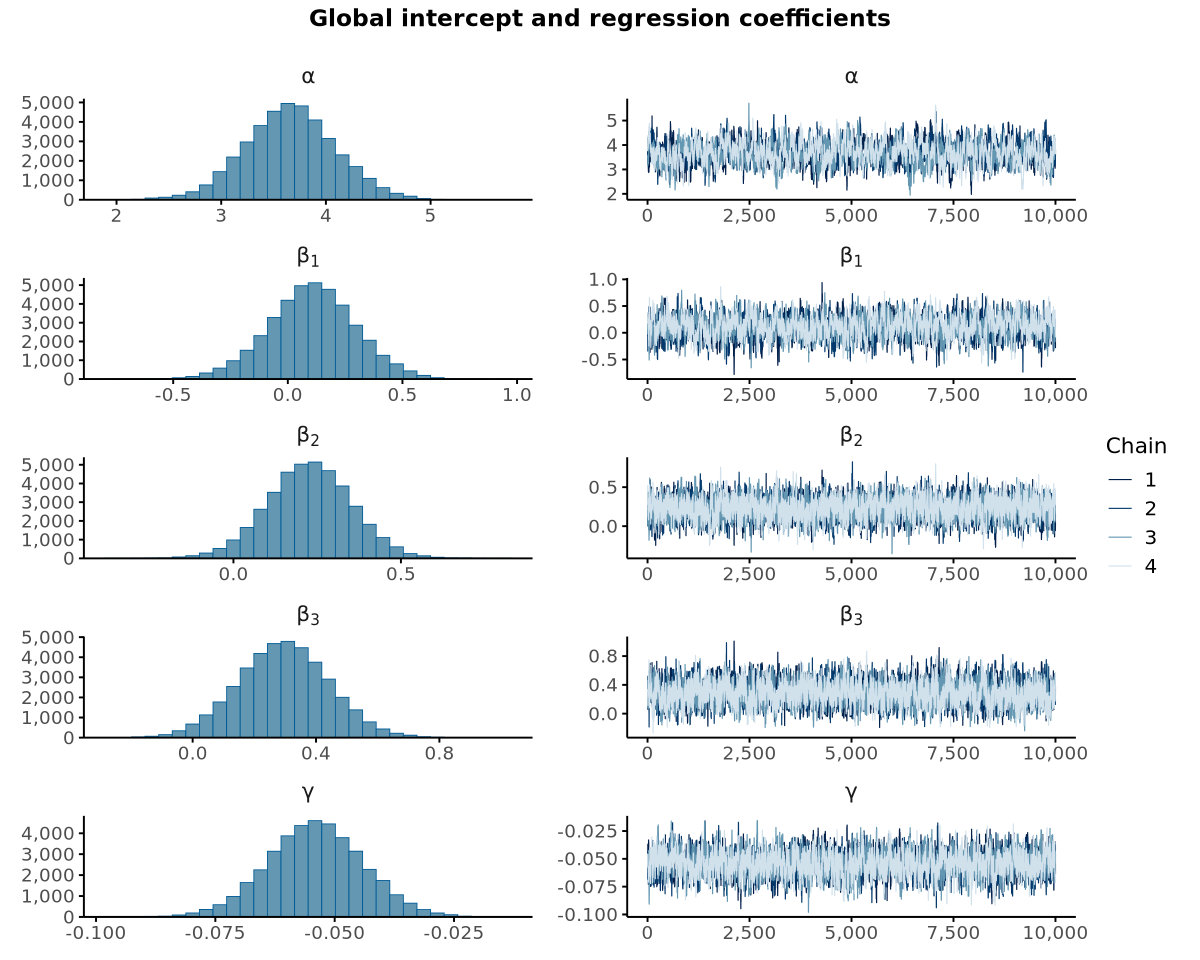

In [12]:
options(repr.plot.height = 8, repr.plot.width = 10)
p1

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


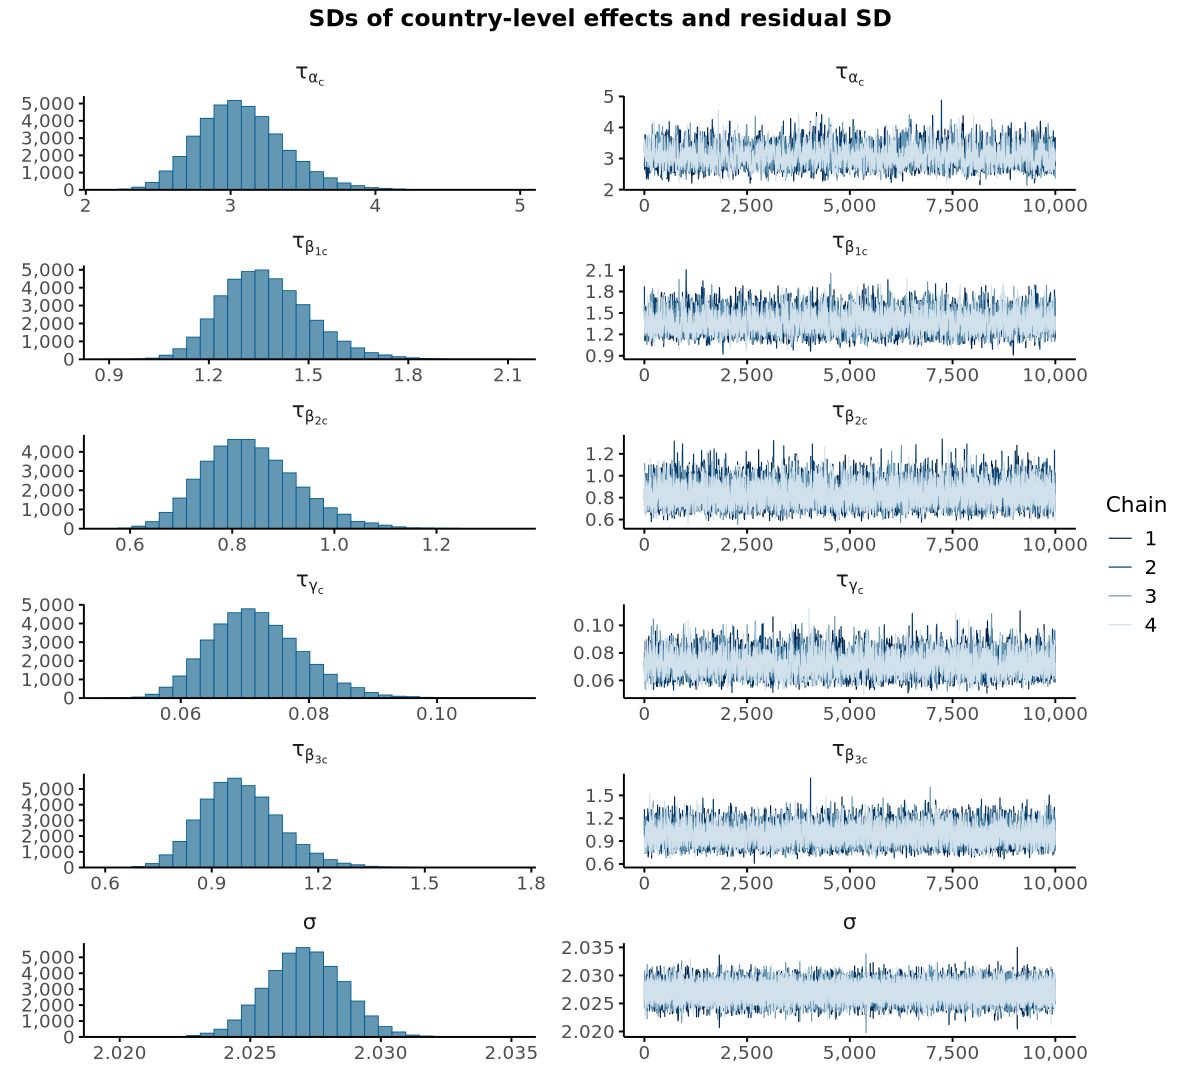

In [13]:
options(repr.plot.height = 9, repr.plot.width = 10)
p2

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


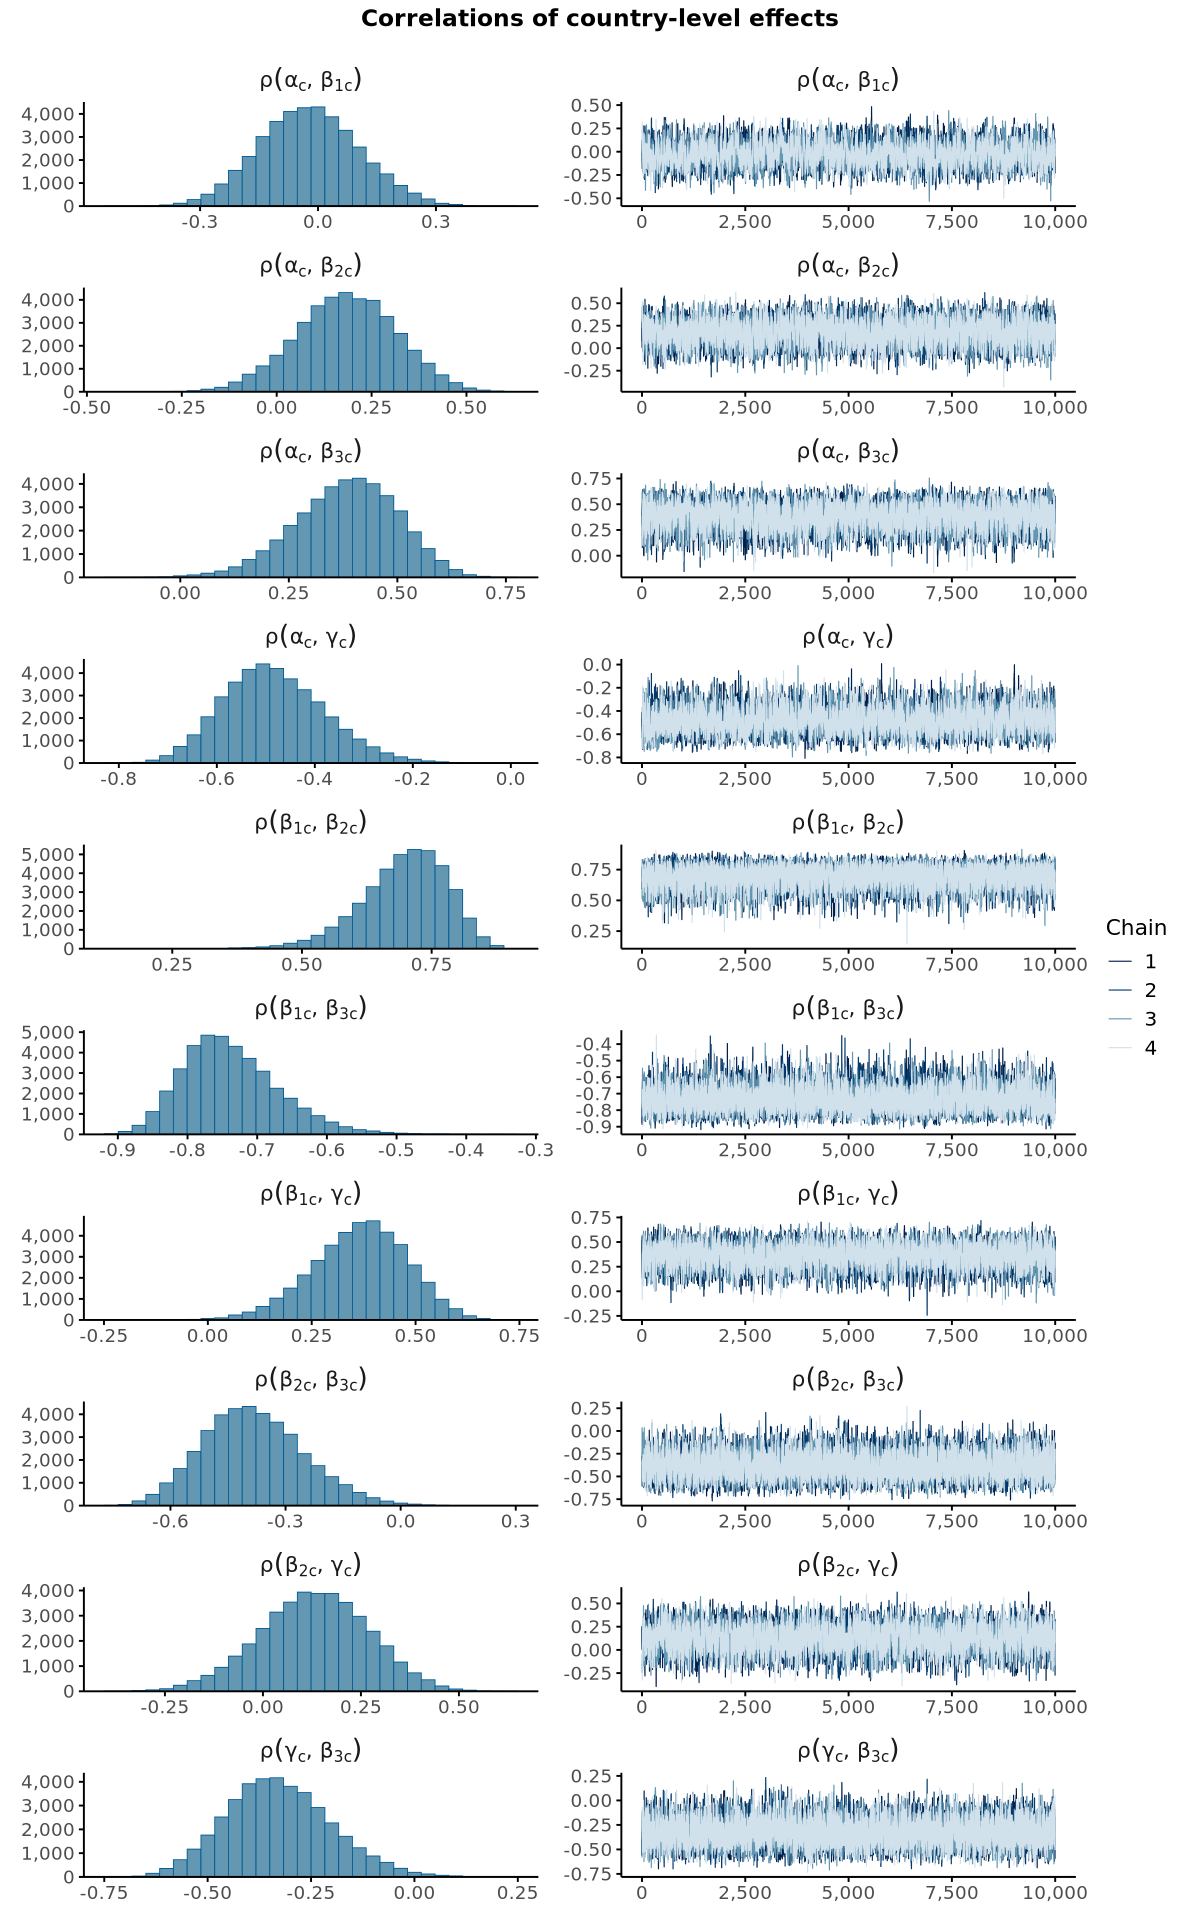

In [14]:
options(repr.plot.height = 16, repr.plot.width = 10)
p3

In [15]:
ggsave(
    plot = p1,
    filename = file.path(root, "paper_results/figures/supplementary_fig_S7a.png"),
    width = 10,
    height = 8,
    dpi = 450,
)
ggsave(
    plot = p2,
    filename = file.path(root, "paper_results/figures/supplementary_fig_S7b.png"),
    width = 10,
    height = 9,
    dpi = 450,
)
ggsave(
    plot = p3,
    filename = file.path(root, "paper_results/figures/supplementary_fig_S7c.png"),
    width = 10,
    height = 16,
    dpi = 450,
)


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
